===== Kruskal MST =====
Edge (0-3) Weight = 5
Edge (2-4) Weight = 5
Edge (3-5) Weight = 6
Edge (0-1) Weight = 7
Edge (1-4) Weight = 7
Edge (4-6) Weight = 9
Total Cost = 39

===== Prim MST =====
Edge (0-3) Weight = 5
Edge (3-5) Weight = 6
Edge (0-1) Weight = 7
Edge (1-4) Weight = 7
Edge (4-2) Weight = 5
Edge (4-6) Weight = 9
Total Cost = 39


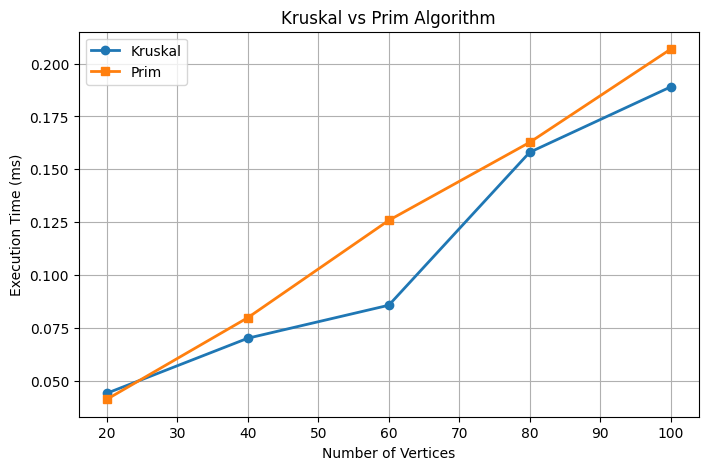

In [1]:
import heapq
import random
import time
import matplotlib.pyplot as plt


# ---------------- Union Find ----------------
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx = self.find(x)
        ry = self.find(y)

        if rx == ry:
            return False

        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx

        self.parent[ry] = rx

        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1

        return True


# ---------------- Kruskal ----------------
def kruskal(n, edges):

    edges = sorted(edges)

    uf = UnionFind(n)

    mst = []
    cost = 0

    for w, u, v in edges:

        if uf.union(u, v):

            mst.append((u, v, w))
            cost += w

            if len(mst) == n - 1:
                break

    return mst, cost


# ---------------- Prim ----------------
def prim(n, adj, start=0):

    visited = [False] * n

    pq = [(0, start, -1)]

    mst = []
    cost = 0

    while pq:

        weight, u, parent = heapq.heappop(pq)

        if visited[u]:
            continue

        visited[u] = True

        if parent != -1:
            mst.append((parent, u, weight))
            cost += weight

        for v, wt in adj.get(u, []):

            if not visited[v]:
                heapq.heappush(pq, (wt, v, u))

    return mst, cost


# ---------------- Sample Graph ----------------
n = 7

edges = [
    (7,0,1),
    (5,0,3),
    (8,1,2),
    (9,1,3),
    (7,1,4),
    (5,2,4),
    (15,3,4),
    (6,3,5),
    (8,4,5),
    (9,4,6),
    (11,5,6)
]

adj = {}

for w, u, v in edges:
    adj.setdefault(u, []).append((v, w))
    adj.setdefault(v, []).append((u, w))


# ---------------- Run Algorithms ----------------
k_mst, k_cost = kruskal(n, edges)
p_mst, p_cost = prim(n, adj)

print("===== Kruskal MST =====")

for u, v, w in k_mst:
    print(f"Edge ({u}-{v}) Weight = {w}")

print("Total Cost =", k_cost)

print("\n===== Prim MST =====")

for u, v, w in p_mst:
    print(f"Edge ({u}-{v}) Weight = {w}")

print("Total Cost =", p_cost)


# ---------------- Performance Analysis ----------------

sizes = [20, 40, 60, 80, 100]

kruskal_time = []
prim_time = []

for size in sizes:

    edges = []

    for _ in range(size * 3):

        u = random.randint(0, size - 1)
        v = random.randint(0, size - 1)

        while u == v:
            v = random.randint(0, size - 1)

        w = random.randint(1, 100)

        edges.append((w, u, v))

    adj = {}

    for w, u, v in edges:
        adj.setdefault(u, []).append((v, w))
        adj.setdefault(v, []).append((u, w))

    # Kruskal Time
    start = time.perf_counter()
    kruskal(size, edges)
    kruskal_time.append((time.perf_counter() - start) * 1000)

    # Prim Time
    start = time.perf_counter()
    prim(size, adj)
    prim_time.append((time.perf_counter() - start) * 1000)


# ---------------- Graph ----------------

plt.figure(figsize=(8,5))

plt.plot(sizes, kruskal_time,
         marker='o',
         linewidth=2,
         label='Kruskal')

plt.plot(sizes, prim_time,
         marker='s',
         linewidth=2,
         label='Prim')

plt.title("Kruskal vs Prim Algorithm")
plt.xlabel("Number of Vertices")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.show()